# Tech Challenge — Fase 1

**Tema:** Saúde da mulher — classificação de câncer de mama (maligno vs benigno)

**Objetivo:** atender às entregas técnicas do PDF — EDA, pré-processamento, dois ou mais modelos, métricas e explicabilidade.

## 1. Contexto e definição do problema

Redes de saúde feminina precisam de **triagem rápida** para priorizar e detectar antecipadamente casos de risco de câncer de mama. Este trabalho não substitui o médico: é um **apoio à decisão** baseado em padrões históricos dos dados.

## 2. Carregamento e exploração inicial dos dados

In [2]:
import pandas as pd

df = pd.read_csv("../data/data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [4]:
df.shape

(569, 33)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

### *Quais são os possíveis valores da variável alvo?*

In [6]:
df['diagnosis'].unique()

<StringArray>
['M', 'B']
Length: 2, dtype: str

### *Sendo assim:*

- **Variáveis Características:** medidas numéricas (ex.: raio, textura, perímetro).
- **Variável Target (o que queremos descobrir):** classe `M -> maligno` ou `B -> benigno`.

### *Quantos registros existem em cada classe?*

In [7]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

### *Existe algum valor faltando no dataset?*

In [8]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

### Dicionário de atributos

- **id**: Identificador único da amostra.
- **diagnosis**: Diagnóstico original no dataset (`M` = maligno, `B` = benigno).
- **radius_mean**: Raio médio dos núcleos celulares.
- **texture_mean**: Textura média dos núcleos celulares.
- **perimeter_mean**: Perímetro médio dos núcleos celulares.
- **area_mean**: Área média dos núcleos celulares.
- **smoothness_mean**: Suavidade média da borda dos núcleos.
- **compactness_mean**: Compacidade média dos núcleos.
- **concavity_mean**: Concavidade média das formas dos núcleos.
- **concave points_mean**: Número médio de pontos côncavos nos núcleos.
- **symmetry_mean**: Simetria média dos núcleos.
- **fractal_dimension_mean**: Dimensão fractal média dos núcleos.
- **radius_se**: Erro padrão do raio dos núcleos.
- **texture_se**: Erro padrão da textura dos núcleos.
- **perimeter_se**: Erro padrão do perímetro dos núcleos.
- **area_se**: Erro padrão da área dos núcleos.
- **smoothness_se**: Erro padrão da suavidade dos núcleos.
- **compactness_se**: Erro padrão da compacidade dos núcleos.
- **concavity_se**: Erro padrão da concavidade dos núcleos.
- **concave points_se**: Erro padrão do número de pontos côncavos.
- **symmetry_se**: Erro padrão da simetria dos núcleos.
- **fractal_dimension_se**: Erro padrão da dimensão fractal.
- **radius_worst**: Maior valor observado de raio nos núcleos.
- **texture_worst**: Maior valor observado de textura nos núcleos.
- **perimeter_worst**: Maior valor observado de perímetro nos núcleos.
- **area_worst**: Maior valor observado de área nos núcleos.
- **smoothness_worst**: Maior valor observado de suavidade nos núcleos.
- **compactness_worst**: Maior valor observado de compacidade nos núcleos.
- **concavity_worst**: Maior valor observado de concavidade nos núcleos.
- **concave points_worst**: Maior valor observado de pontos côncavos nos núcleos.
- **symmetry_worst**: Maior valor observado de simetria nos núcleos.
- **fractal_dimension_worst**: Maior dimensão fractal observada nos núcleos.

Observação: a coluna Unnamed: 32 pode ser descartada, pois não contém valores relevantes e a coluna id também por ser somente identificação.

In [9]:
df_clean = df.drop(
    columns=[
        'id',
        'Unnamed: 32',
        'diagnosis'
    ]
)

df_clean.shape

(569, 30)

### *O conjunto de dados está balanceado entre tumores benignos e malignos?*

In [10]:
df['diagnosis'].value_counts(normalize=True) * 100

diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64

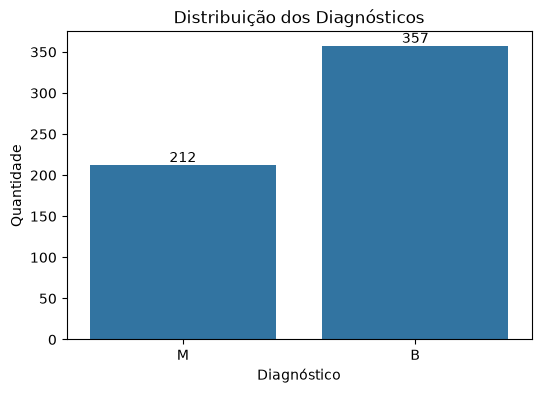

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x='diagnosis'
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Distribuição dos Diagnósticos')
plt.xlabel('Diagnóstico')
plt.ylabel('Quantidade')

plt.show()

A análise da variável alvo mostrou que o conjunto de dados possui 357 amostras classificadas como benignas (62,7%) e 212 amostras classificadas como malignas (37,3%). Embora exista uma predominância da classe benigna, a diferença entre as classes não é muito grande para caracterizar um desbalanceamento severo. Dessa forma, inicialmente não será necessária a aplicação de técnicas de balanceamento.

### *As características apresentam grande variabilidade entre as amostras?*

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


#

### *Os tumores malignos apresentam dimensões maiores que os benignos?*

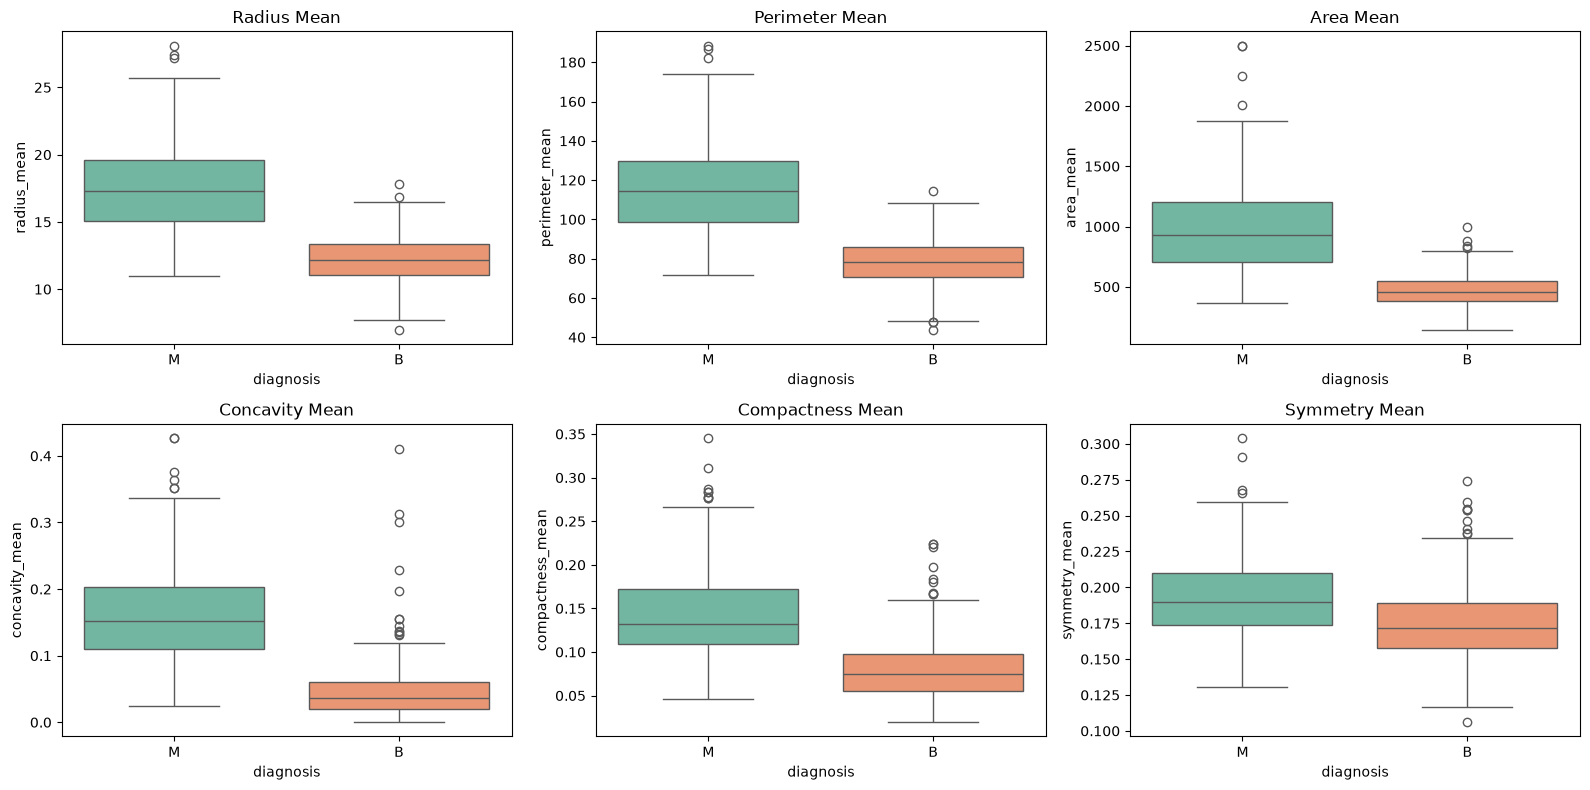

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

colunas = [
    'radius_mean',
    'perimeter_mean',
    'area_mean',
    'concavity_mean',
    'compactness_mean',
    'symmetry_mean'
]

for ax, coluna in zip(axes.flat, colunas):
    sns.boxplot(
        data=df,
        x='diagnosis',
        y=coluna,
        hue='diagnosis',
        palette='Set2',
        ax=ax,
        legend=False
    )
    ax.set_title(coluna.replace('_', ' ').title())

plt.tight_layout()
plt.show()

A análise dos boxplots mostra que tumores classificados como malignos apresentam, em geral, valores mais elevados para raio médio (radius_mean), perímetro médio (perimeter_mean), área média (area_mean) e concavidade média (concavity_mean) quando comparados aos tumores benignos.

Observa-se também que as medianas dos grupos encontram-se claramente separadas, onde os valores dos tumores malignos se concentram em faixas superiores às observadas nos tumores benignos, indicando que essas características podem ser importantes para diferenciar os dois tipos de diagnóstico e devem ser consideradas no treinamento dos modelos de classificação.

### *Existem outliers relevantes nessas características?*

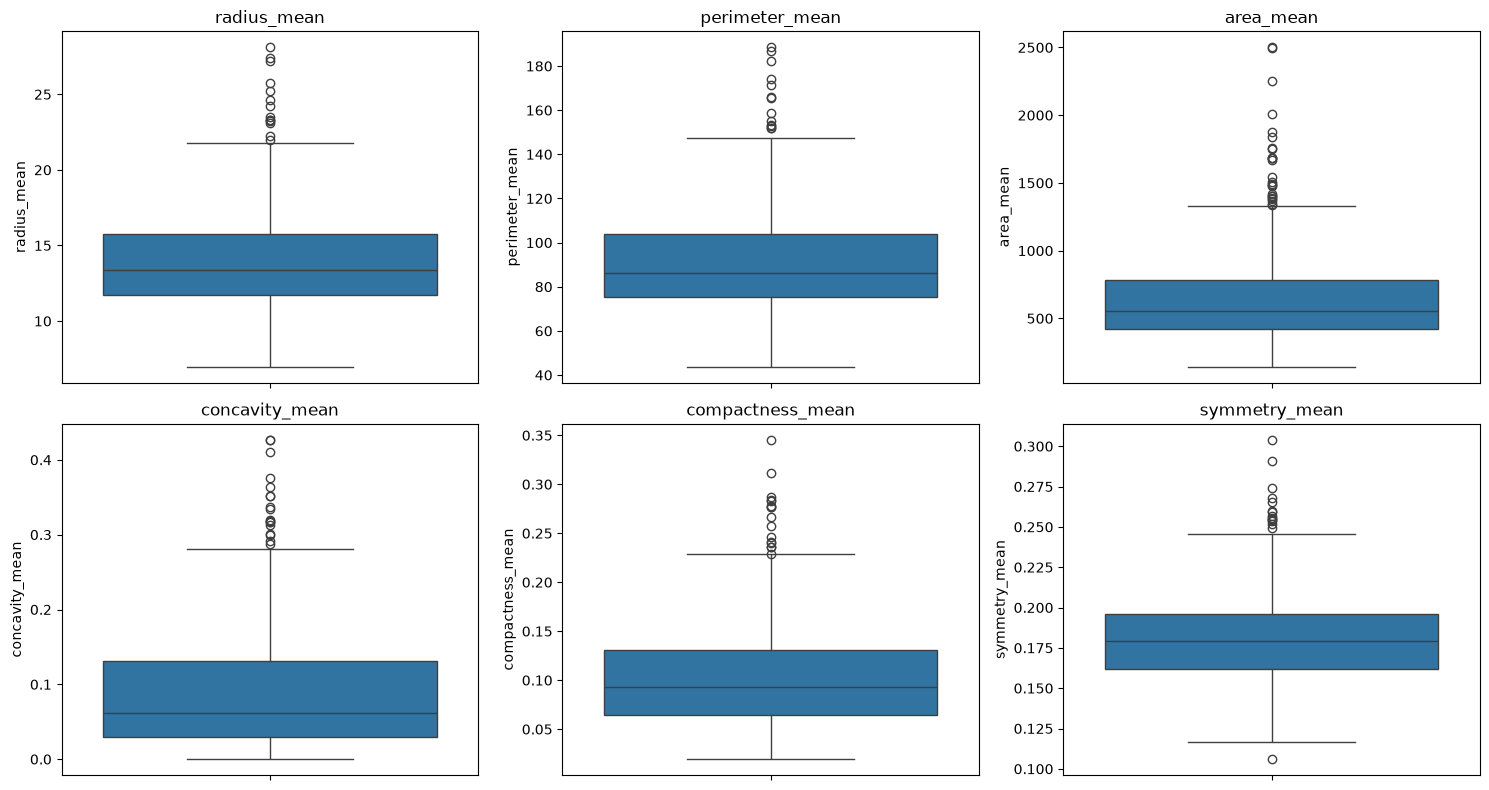

In [14]:
features = [
    'radius_mean',
    'perimeter_mean',
    'area_mean',
    'concavity_mean',
    'compactness_mean',
    'symmetry_mean'
]

fig, axes = plt.subplots(2, 3, figsize=(15,8))

for ax, col in zip(axes.flatten(), features):
    sns.boxplot(
        y=df[col],
        ax=ax
    )
    ax.set_title(col)

plt.tight_layout()
plt.show()

A análise dos boxplots revela a presença de valores extremos em todas as variáveis avaliadas.

Esses valores aparecem acima do limite superior dos boxplots, indicando observações que se encontram distantes da maior parte dos registros da amostra.

Entretanto, considerando que o conjunto de dados representa características reais de câncer de mama, esses outliers podem representar tumores genuinamente maiores ou mais agressivos. Como não há evidência de erro nos dados, optou-se por mantê-los para não perder informação clínica relevante.

### *As distribuições dessas dimensões são diferentes entre tumores benignos e malignos?*

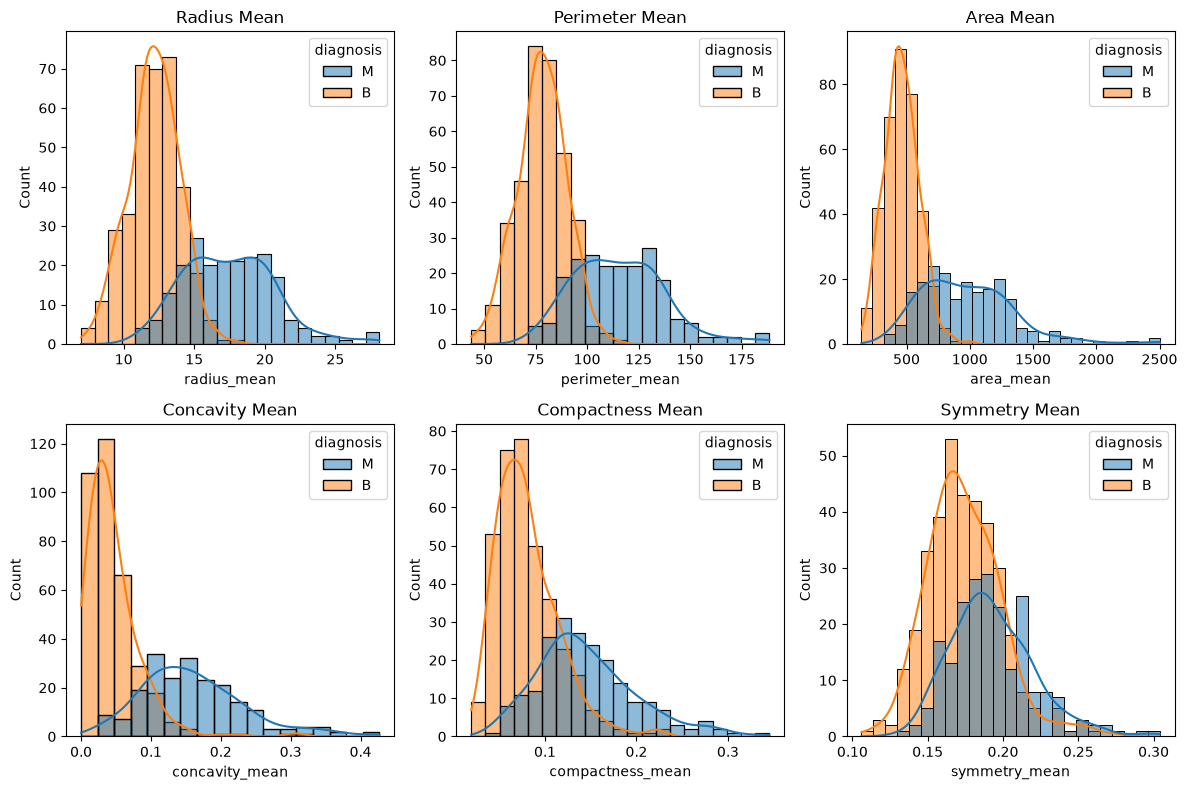

In [15]:
features = [
    'radius_mean',
    'perimeter_mean',
    'area_mean',
    'concavity_mean',
    'compactness_mean',
    'symmetry_mean'
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, col in zip(axes.flat, features):
    sns.histplot(
        data=df,
        x=col,
        hue='diagnosis',
        kde=True,
        ax=ax
    )
    ax.set_title(col.replace('_', ' ').title())

plt.tight_layout()
plt.show()

*radius_mean*
- Os tumores benignos (laranja) se concentram principalmente entre 10 e 15.
- Os malignos (azul) aparecem em valores mais altos, geralmente acima de 14.
- Existe uma região de sobreposição entre aproximadamente 13 e 17.

*perimeter_mean*
- Benignos se concentram entre 60 e 90.
- Malignos entre 90 e 140.
- Há alguma sobreposição, mas os grupos parecem relativamente distintos.

*area_mean*
- Os benignos se concentram em áreas menores.
- Os malignos apresentam áreas consideravelmente maiores.
- A distribuição dos malignos é deslocada para a direita.

*concavity_mean*
- Também mostra boa capacidade de diferenciação.
- A maioria dos benignos possui concavidade próxima de zero.
- Os malignos apresentam valores mais elevados e distribuídos em uma faixa mais ampla.


A análise dos histogramas confirma os padrões observados anteriormente nos boxplots. As variáveis radius_mean, perimeter_mean, area_mean e concavity_mean apresentam distribuições distintas para tumores benignos e malignos.

As variáveis relacionadas ao tamanho do tumor (radius_mean, perimeter_mean e area_mean) mostram um deslocamento das distribuições dos tumores malignos para valores mais elevados quando comparados aos tumores benignos. Embora exista uma região de sobreposição entre as classes, observa-se uma tendência clara de que tumores malignos possuam maiores dimensões.

A variável concavity_mean também demonstra capacidade de diferenciação, uma vez que os tumores benignos concentram-se em valores mais baixos de concavidade, enquanto os malignos apresentam valores mais elevados e dispersos.

Esses resultados indicam que tais características possuem potencial para auxiliar os algoritmos de classificação na identificação do diagnóstico dos tumores.

### *Tumores com maior área tendem a apresentar maior assimetria?*

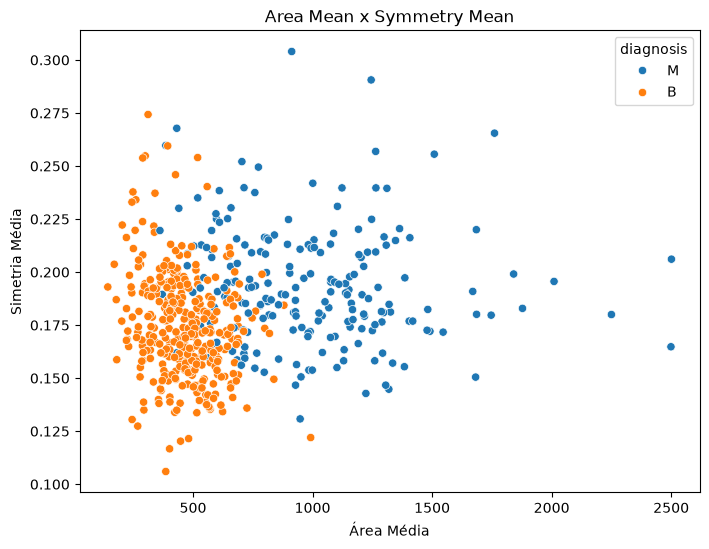

In [16]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='area_mean',
    y='symmetry_mean',
    hue='diagnosis'
)

plt.title('Area Mean x Symmetry Mean')
plt.xlabel('Área Média')
plt.ylabel('Simetria Média')

plt.show()

Observa-se que os tumores malignos tendem a apresentar áreas maiores quando comparados aos tumores benignos, formando uma concentração de pontos em regiões mais elevadas do eixo de área.

Entretanto, não foi identificada uma relação linear clara entre área e simetria. Os valores de simetria permanecem relativamente dispersos ao longo de toda a faixa de áreas observadas, indicando que tumores maiores não são necessariamente mais assimétricos.

Esse resultado sugere que as variáveis area_mean e symmetry_mean representam características distintas dos tumores e podem contribuir de forma complementar para os modelos de classificação.

## 3. Análise de correlação

### *Quais variáveis possuem maior relação com o diagnóstico?*

In [17]:
df_corr = df.copy()

df_corr['diagnosis'] = df_corr['diagnosis'].map({
    'B': 0,
    'M': 1
})

corr_target = (
    df_corr
    .corr(numeric_only=True)['diagnosis']
    .abs()
    .sort_values(ascending=False)
)

corr_target.head(15)

diagnosis               1.000000
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
compactness_mean        0.596534
compactness_worst       0.590998
radius_se               0.567134
perimeter_se            0.556141
Name: diagnosis, dtype: float64

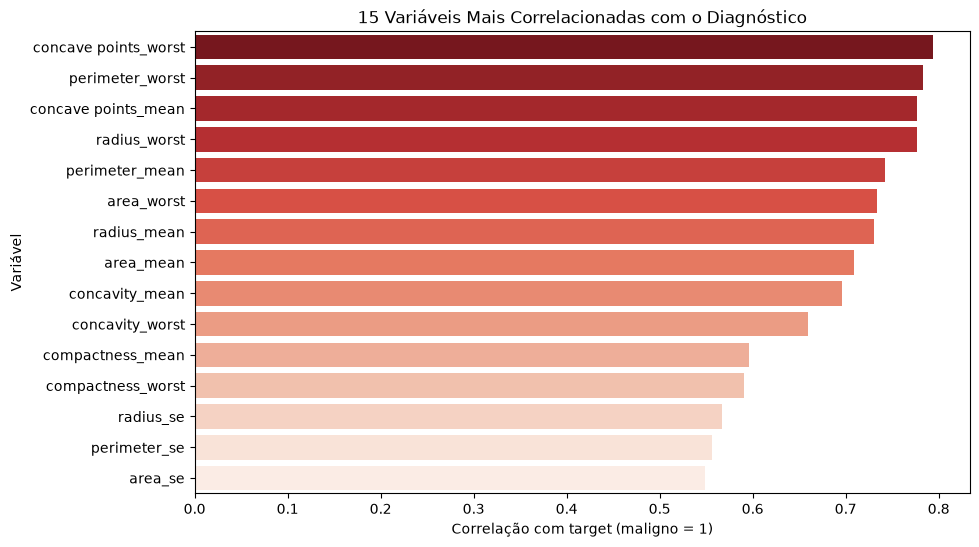

In [18]:
top15_corr = corr_target.iloc[1:16]

plt.figure(figsize=(10,6))

sns.barplot(
    x=top15_corr.values,
    y=top15_corr.index,
    hue=top15_corr.index,
    palette="Reds_r"
)

plt.title(
    '15 Variáveis Mais Correlacionadas com o Diagnóstico'
)

plt.xlabel('Correlação com target (maligno = 1)')
plt.ylabel('Variável')

plt.show()

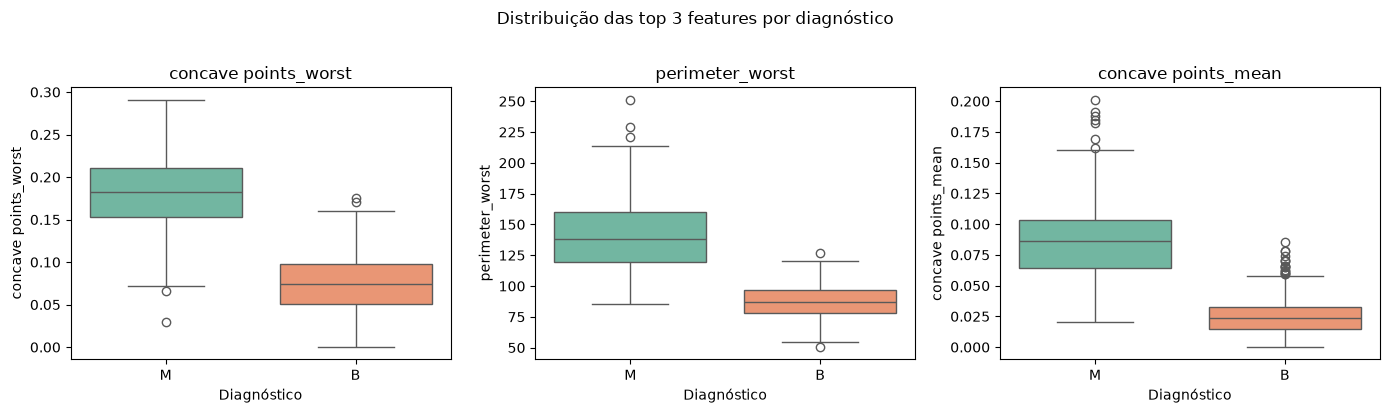

In [19]:
top_features = corr_target.drop('diagnosis').head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feat in zip(axes, top_features):
    sns.boxplot(data=df, x="diagnosis", y=feat, hue="diagnosis", ax=ax, palette="Set2", legend=False)
    ax.set_title(feat)
    ax.set_xlabel("Diagnóstico")

plt.suptitle("Distribuição das top 3 features por diagnóstico", y=1.02)
plt.tight_layout()
plt.show()

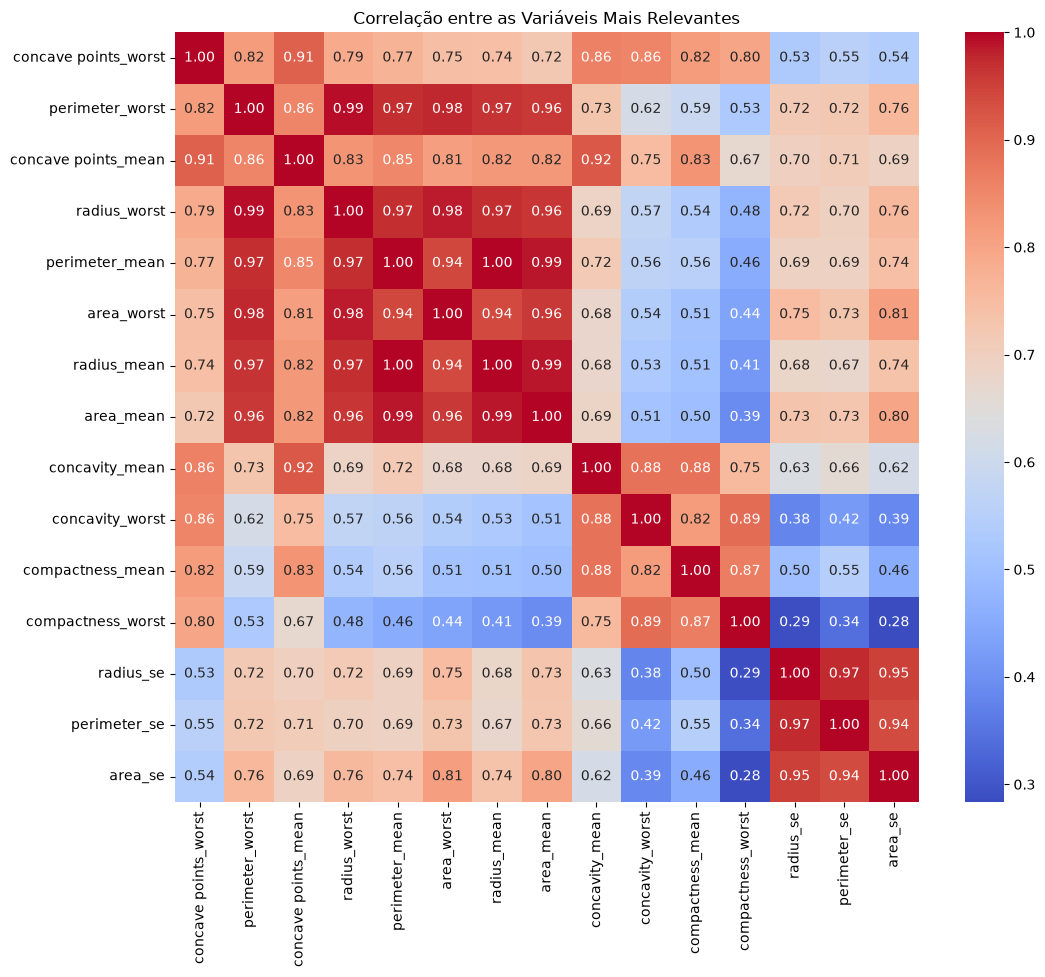

In [20]:
top_cols = top15_corr.index.tolist()

plt.figure(figsize=(12,10))

sns.heatmap(
    df_corr[top_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    'Correlação entre as Variáveis Mais Relevantes'
)

plt.show()

A matriz de correlação mostra que algumas variáveis apresentam correlação muito elevada entre si. Destacam-se principalmente radius_worst, perimeter_worst e area_worst, que possuem forte associação por representarem diferentes medidas do tamanho do tumor.

Esse comportamento sugere a existência de redundância entre atributos, indicando que alguns modelos podem se beneficiar de técnicas de seleção de variáveis ou regularização para reduzir o impacto da multicolinearidade.

Também foi observado que características relacionadas à concavidade e aos pontos côncavos apresentam forte associação com o diagnóstico, reforçando sua relevância para a tarefa de classificação.

## 4. Avaliação da dimensionalidade com PCA

### *Avaliação da dimensionalidade com PCA* - Existe redundância entre as variáveis?

In [21]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_clean)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=df_clean.columns
)

X_scaled.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [22]:
from sklearn.decomposition import PCA

pca = PCA()

pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

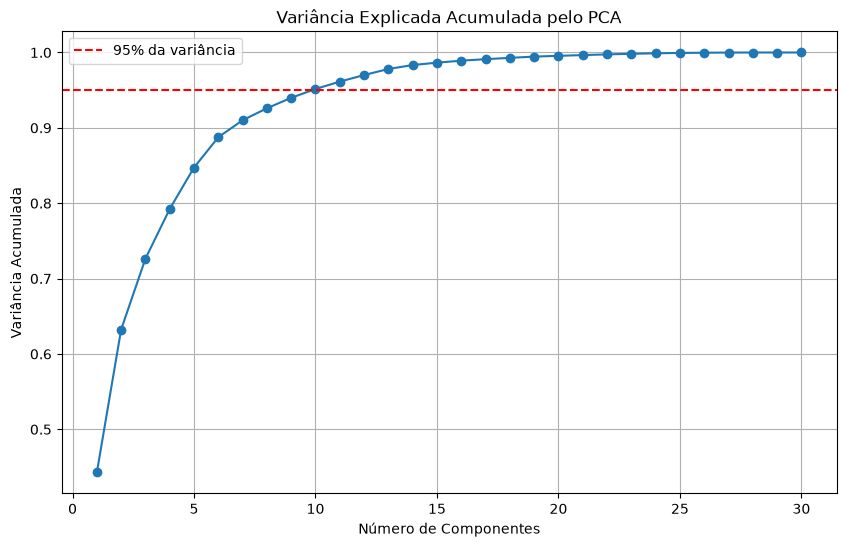

Componentes para ~95% da variância: 10


In [23]:
import numpy as np

explained_variance = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(10,6))
plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance,
    marker='o'
)
plt.axhline(
    y=0.95,
    color='red',
    linestyle='--',
    label='95% da variância'
)
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Acumulada')
plt.title(
    'Variância Explicada Acumulada pelo PCA'
)
plt.legend()
plt.grid(True)
plt.show()


n_95 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
print(f"Componentes para ~95% da variância: {n_95}")

Embora o conjunto de dados possua 30 dimensões, observou-se que aproximadamente 95% da variância total pode ser representada por apenas 10 componentes principais. Esse resultado sugere a existência de redundância entre as variáveis originais, como por exemplo: radius_mean, perimeter_mean, area_mean, que carregam informações parecidas.

## 5. Pré-processamento e separação treino/teste

In [24]:
X = df_clean

y = df['diagnosis'].map({
    'B': 0,
    'M': 1
})

print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")
print(f"Distribuição treino — benigno: {(y_train==0).sum()} | maligno: {(y_train==1).sum()}")
print(f"Distribuição teste  — benigno: {(y_test==0).sum()}  | maligno: {(y_test==1).sum()}")

Treino: 455 amostras | Teste: 114 amostras
Distribuição treino — benigno: 285 | maligno: 170
Distribuição teste  — benigno: 72  | maligno: 42


In [26]:
# Padronização: fit apenas no treino, aplica no teste para evitar data leakage
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verificação: após escalar, média ≈ 0 e desvio ≈ 1 no treino
means = X_train_scaled.mean(axis=0).round(6)
stds  = X_train_scaled.std(axis=0).round(3)

print(f"Média das features no treino (deve ser ≈ 0): {means[:5]}")
print(f"Desvio das features no treino (deve ser ≈ 1): {stds[:5]}")


Média das features no treino (deve ser ≈ 0): [-0.  0.  0. -0.  0.]
Desvio das features no treino (deve ser ≈ 1): [1. 1. 1. 1. 1.]


Como as variáveis do conjunto de dados apresentam escalas bastante diferentes, foi aplicada a técnica de padronização utilizando o StandardScaler.

A padronização foi ajustada apenas sobre o conjunto de treinamento (fit_transform) e posteriormente aplicada ao conjunto de teste (transform), evitando vazamento de informações (data leakage).

Após a transformação, as variáveis passaram a apresentar média próxima de zero e desvio padrão próximo de um, condição desejável para algoritmos sensíveis à escala dos dados, como a Regressão Logística.

## 6. Modelagem — três algoritmos

### 6.1 Regressão Linear

In [27]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](30,)","[-0.74, 0.02, 0.74,...,-0.06, 0.08, 0.08]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.3736
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,30
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,30
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](30,)","[78.02,50.31,36.17,..., 0.83, 0.59, 0.24]"


In [28]:
y_pred_lr = lr.predict(X_test_scaled)

y_pred_lr[:10]

array([ 0.06966653,  1.09664198,  0.20027622,  0.50239576,  0.37947312,
       -0.11327387,  0.46018815,  0.04095547,  0.12958325,  0.14863396])

In [29]:
y_pred_lr_class = (y_pred_lr >= 0.5).astype(int)

y_pred_lr_class[:10]

array([0, 1, 0, 1, 0, 0, 0, 0, 0, 0])

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy:", accuracy_score(y_test, y_pred_lr_class))

print("Precision:", precision_score(y_test, y_pred_lr_class))

print("Recall:", recall_score(y_test, y_pred_lr_class))

print("F1:", f1_score(y_test, y_pred_lr_class))

Accuracy: 0.9649122807017544
Precision: 1.0
Recall: 0.9047619047619048
F1: 0.95


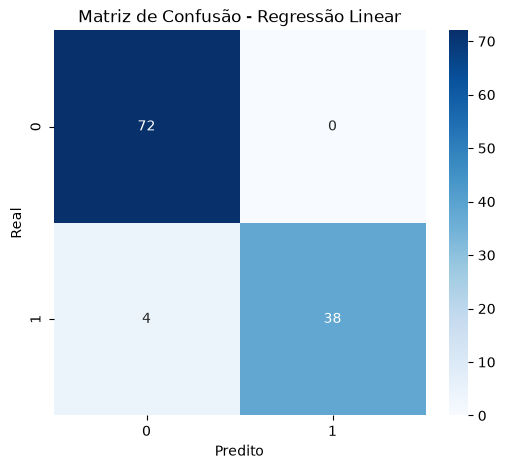

In [35]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr_class
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Matriz de Confusão - Regressão Linear'
)

plt.xlabel('Predito')
plt.ylabel('Real')

plt.show()

O modelo de Regressão Linear foi treinado utilizando os dados padronizados e suas previsões contínuas foram convertidas em classes por meio de um limiar de 0,5.

Os resultados obtidos foram bastante satisfatórios, alcançando acurácia de 96,49%, precisão de 100%, recall de 90,48% e F1-Score de 95%.

A matriz de confusão mostrou que todos os tumores benignos foram corretamente classificados, não havendo ocorrência de falsos positivos. Entretanto, quatro tumores malignos foram classificados incorretamente como benignos, reduzindo o valor de recall.

Embora o desempenho tenha sido bom, é importante destacar que a Regressão Linear não funciona muito bem para problemas de classificação, uma vez que produz previsões contínuas que precisam ser posteriormente convertidas em classes. Dessa forma, é relevante comparar os resultados com algoritmos específicos para classificação, como Regressão Logística ou Random Forest.

### 6.2 Regressão Logística

In [33]:
from sklearn.linear_model import LogisticRegression

log = LogisticRegression(random_state=42, max_iter=5000)

log.fit(X_train_scaled, y_train)

y_pred_log = log.predict(X_test_scaled)

y_pred_log[:10]

array([0, 1, 0, 1, 1, 0, 1, 0, 0, 0])

In [34]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))

print("Precision:", precision_score(y_test, y_pred_log))

print("Recall:", recall_score(y_test, y_pred_log))

print("F1:", f1_score(y_test, y_pred_log))

Accuracy: 0.9649122807017544
Precision: 0.975
Recall: 0.9285714285714286
F1: 0.9512195121951219


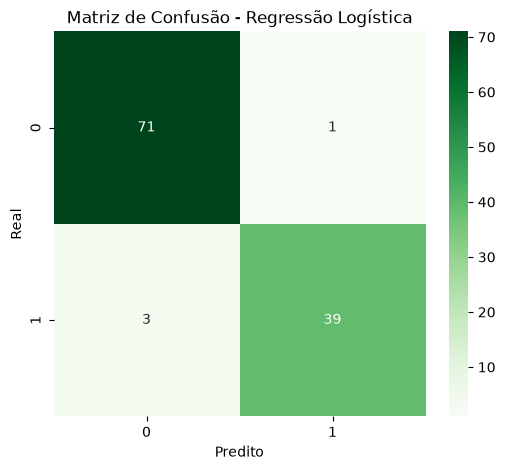

In [36]:
cm_log = confusion_matrix(
    y_test,
    y_pred_log
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_log,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    'Matriz de Confusão - Regressão Logística'
)

plt.xlabel('Predito')
plt.ylabel('Real')

plt.show()

### 6.3 RandomForestClassifier

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

print(y_pred_rf[:10])
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))

[0 1 0 1 0 0 1 0 0 0]
Accuracy: 0.9736842105263158
Precision: 1.0
Recall: 0.9285714285714286
F1: 0.9629629629629629


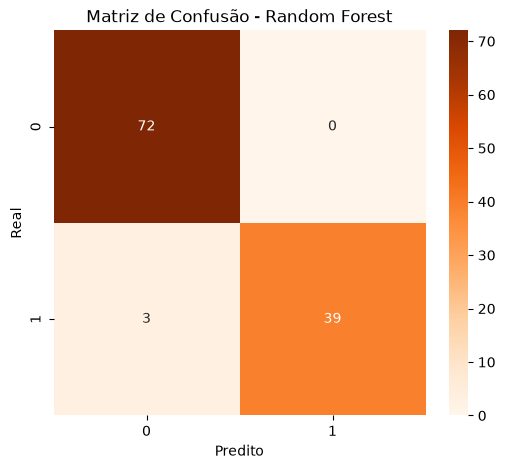

In [42]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title(
    'Matriz de Confusão - Random Forest'
)

plt.xlabel('Predito')
plt.ylabel('Real')

plt.show()

In [43]:
resultados = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'Regressão Logística', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr_class),
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr_class),
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr_class),
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    'F1': [
        f1_score(y_test, y_pred_lr_class),
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1
0,Regressão Linear,0.964912,1.000,0.904762,0.950000
1,Regressão Logística,0.964912,0.975,0.928571,0.951220
2,Random Forest,0.973684,1.000,0.928571,0.962963


### *Existe overfitting no modelo Random Forest?*

In [44]:
train_score = rf.score(X_train_scaled, y_train)

test_score = rf.score(X_test_scaled, y_test)

print(f"Random Forest - Acurácia no Treino: {train_score:.4f}")
print(f"Random Forest - Acurácia no Teste: {test_score:.4f}")

Random Forest - Acurácia no Treino: 1.0000
Random Forest - Acurácia no Teste: 0.9737


Os três modelos avaliados apresentaram desempenho alto, com acurácia superior a 96%, dessa forma o conjunto de dados possui características capazes de distinguir de forma correta tumores benignos e malignos.

O modelo Random Forest apresentou o melhor resultado geral, alcançando acurácia de 97,37% no conjunto de teste. Embora tenha obtido 100% de acurácia no conjunto de treinamento, a diferença observada para o conjunto de teste foi pequena (2,63 pontos percentuais), não caracterizando um caso severo de overfitting, visto que a análise exploratória revelou uma clara separação entre as dimensões para diversas características do conjunto de dados, o que contribui para a capacidade preditiva dos algoritmos.

A Regressão Logística apresentou desempenho muito próximo ao Random Forest, demonstrando que as classes possuem boa separação linear. Já a Regressão Linear, apesar de não ser um algoritmo desenvolvido para classificação, obteve resultados satisfatórios após a conversão das previsões contínuas em classes binárias.

Considerando as métricas obtidas, conclui-se que o Random Forest foi o modelo mais adequado para este problema, apresentando o melhor equilíbrio entre capacidade preditiva e generalização.


## 7. Explicabilidade — importância das variáveis e SHAP

In [45]:
importancias = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importancias = importancias.sort_values(
    by='Importance',
    ascending=False
)

importancias.head(10)

,Feature,Importance
23,area_worst,0.151412
27,concave points_worst,0.126497
20,radius_worst,0.093475
22,perimeter_worst,0.083642
7,concave points_mean,0.081082
2,perimeter_mean,0.077126
0,radius_mean,0.061990
6,concavity_mean,0.050818
3,area_mean,0.045916
26,concavity_worst,0.030022


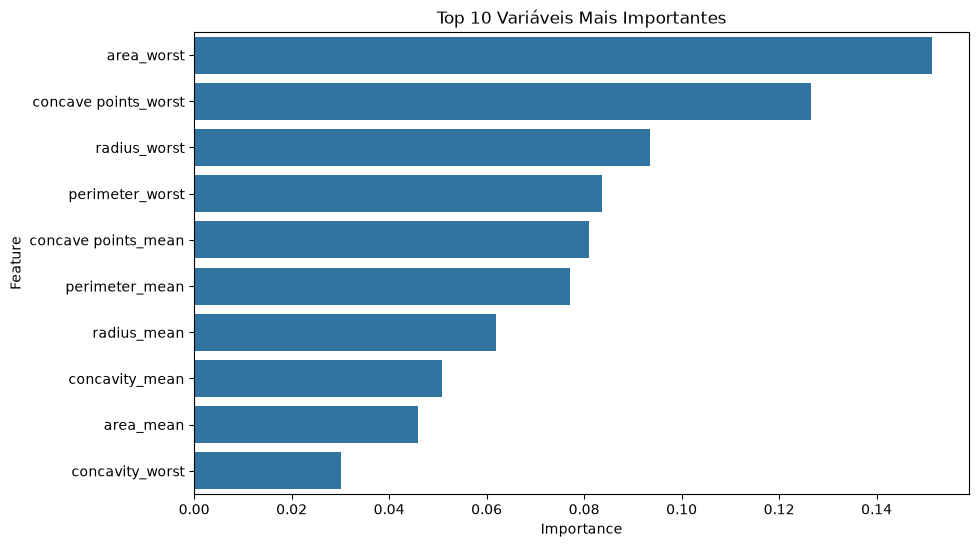

In [46]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importancias.head(10),
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 10 Variáveis Mais Importantes'
)

plt.show()

## 8. Discussão crítica

### *Análise da variável alvo*

A variável alvo do estudo é diagnosis, responsável por indicar o diagnóstico do tumor analisado. Foram identificadas duas classes distintas:

M (Maligno): tumor maligno;
B (Benigno): tumor benigno.

A distribuição das classes apresentou 357 amostras benignas e 212 amostras malignas, totalizando 569 registros. Apesar da predominância da classe benigna, o conjunto de dados não apresenta um desbalanceamento severo, permitindo a aplicação de algoritmos de classificação sem necessidade imediata de técnicas de balanceamento.


A coluna id é apenas um identificador e não possui valor preditivo para o diagnóstico.


### *A análise de Componentes Principais (PCA)*
A análise de Componentes Principais (PCA) foi realizada com o objetivo de avaliar a dimensionalidade efetiva do conjunto de dados e identificar possíveis redundâncias entre os variáveis.

Observou-se que aproximadamente 95% da variância total dos dados pode ser explicada por apenas 10 componentes principais, embora o conjunto original possua 30 variáveis. Esse resultado sugere que parte significativa dos atributos apresenta informações correlacionadas ou redundantes.

A redução de dimensionalidade observada reforça os resultados obtidos anteriormente na análise de correlação, que indicaram forte associação entre diversas características relacionadas ao tamanho e à forma dos tumores.





- **Métrica prioritária sugerida:** **recall** da classe maligna — errar um caso maligno (falso negativo) costuma ser mais grave que um falso positivo.